In [35]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv


In [36]:
load_dotenv()

True

In [37]:
model = ChatGroq(model="openai/gpt-oss-120b")

In [38]:
class Blogger(TypedDict):
    topic: str
    outline: str
    blog: str
    score: int

In [39]:
def generate_outline(state: Blogger) -> Blogger:
    topic = state['topic']

    outline_prompt = f"Generate a detailed outline for a blog post about the following topic: {topic}"

    outline = model.invoke(outline_prompt).content

    state['outline'] = outline

    return state

In [40]:
def blog_from_outline(state: Blogger) -> Blogger:

    topic = state['topic']
    
    outline = state['outline']

    blog_prompt = f"Write a detailed blog post based on the following outline: {outline}"

    blog = model.invoke(blog_prompt).content

    state['blog'] = blog

    return state

In [44]:
def score_blog(state: Blogger) ->Blogger:

    topic = state['topic']

    outline = state['outline']

    blog = state['blog']

    score_prompt = f"Score the following blog post on a scale of 1-10 based on how well it adheres to the following topic and outline. Topic: {topic} Outline: {outline} Blog Post: {blog}"

    score = model.invoke(score_prompt).content

    state['score'] = score

    return state

In [45]:
graph = StateGraph(Blogger)

graph.add_node('generate_outline', generate_outline)

graph.add_node('blog_from_outline', blog_from_outline)

graph.add_node('score_blog', score_blog)

graph.add_edge(START, 'generate_outline')

graph.add_edge('generate_outline', 'blog_from_outline')

graph.add_edge('blog_from_outline', 'score_blog')

graph.add_edge('score_blog', END)

workflow = graph.compile()

In [46]:
initial_state = {'topic': "The benefits of using AI in education"}

final_state = workflow.invoke(initial_state)

print(final_state)

**The Benefits of Using AI in Education: How Intelligent Technologies Are Transforming Learning**  

---

### 1. Introduction  

**Hook** – *“Students who used AI‑powered tutoring platforms improved test scores by up to 20 %.”*  

That headline isn’t hype; it’s the result of dozens of controlled studies published in the last five years. From adaptive math engines that re‑order problems on the fly to conversational chat‑bots that practice pronunciation 24/7, artificial intelligence is already reshaping the classroom.  

**What is AI in education?**  
At its core, AI in education is the application of **machine‑learning algorithms, natural‑language processing (NLP), computer vision, and predictive analytics** to teaching and learning. These technologies can sense a learner’s current state, predict what they need next, and deliver the right content at the right moment.  

**Why should you care?**  
Whether you’re a teacher juggling lesson planning, an administrator tasked with tightening 

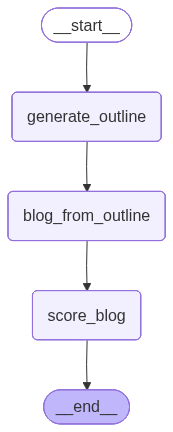

In [47]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [52]:
print(final_state['blog'])

**The Benefits of Using AI in Education: How Intelligent Technologies Are Transforming Learning**  

---

### 1. Introduction  

**Hook** – *“Students who used AI‑powered tutoring platforms improved test scores by up to 20 %.”*  

That headline isn’t hype; it’s the result of dozens of controlled studies published in the last five years. From adaptive math engines that re‑order problems on the fly to conversational chat‑bots that practice pronunciation 24/7, artificial intelligence is already reshaping the classroom.  

**What is AI in education?**  
At its core, AI in education is the application of **machine‑learning algorithms, natural‑language processing (NLP), computer vision, and predictive analytics** to teaching and learning. These technologies can sense a learner’s current state, predict what they need next, and deliver the right content at the right moment.  

**Why should you care?**  
Whether you’re a teacher juggling lesson planning, an administrator tasked with tightening 

In [53]:
print(final_state['outline'])

**Title:** *The Benefits of Using AI in Education: How Intelligent Technologies Are Transforming Learning*  

---

## 1. Introduction  
- **Hook:** A striking statistic or anecdote (e.g., “Students who used AI‑powered tutoring platforms improved test scores by up to 20%”)  
- **Brief definition of AI in education:** machine‑learning algorithms, natural‑language processing, computer vision, and predictive analytics applied to teaching and learning.  
- **Purpose of the post:** Explain why educators, administrators, students, and policymakers should care about AI, and preview the main benefits.  
- **Thesis statement:** AI is not a replacement for teachers; it is a powerful augmentative tool that personalizes learning, streamlines operations, expands access, and drives data‑informed decision‑making.

---

## 2. Personalized Learning at Scale  
### 2.1 Adaptive Learning Paths  
- Real‑time assessment of learner proficiency.  
- Dynamic content sequencing (e.g., Khan Academy, DreamBox).  


In [49]:
print(final_state['score'])

**Score: 9 / 10**

### Why the post scores high

| Outline Element | How the Post Meets It | Comments |
|-----------------|----------------------|----------|
| **Title** | Exact title from the outline is used. | ✅ |
| **1. Introduction** | ✔ Hook with a striking statistic. <br>✔ Clear definition of AI in education (ML, NLP, CV, predictive analytics). <br>✔ Purpose statement for educators, admins, students, policymakers. <br>✔ Thesis that AI augments—not replaces—teachers. | All required bullets are present and concise. |
| **2. Personalized Learning at Scale** | All sub‑sections (2.1‑2.4) are covered: adaptive paths, ITS, learning‑style/pace customization, impact evidence. Real‑world examples (Khan Academy, DreamBox, Duolingo) are included. | Good depth and empirical data. |
| **3. Enhancing Teaching Efficiency** | Covers automated grading, content creation/curation, administrative automation, teacher support/PD. Specific tools and benefits are described. | Matches outline perfectly. |